In [1]:
!git clone https://github.com/nithinganesh1/Image_Classification.git

Cloning into 'Image_Classification'...
remote: Enumerating objects: 516, done.
remote: Counting objects: 100% (173/173), done.
remote: Compressing objects: 100% (134/134), done.
remote: Total 516 (delta 83), reused 93 (delta 38), pack-reused 343 (from 1)
Receiving objects: 100% (516/516), 110.42 MiB | 19.80 MiB/s, done.
Resolving deltas: 100% (93/93), done.


In [2]:
cd /content/Image_Classification

/content/Image_Classification


In [3]:
import tensorflow as tf
import os

In [4]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
import cv2
import imghdr

/tmp/ipykernel_580/4232469594.py:2: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


In [6]:
data_dir = 'data'

In [7]:
image_exts = ['jpeg','jpg', 'bmp', 'png']


In [10]:
for image_class in os.listdir(data_dir):
    for image in os.listdir(os.path.join(data_dir, image_class)):
        image_path = os.path.join(data_dir, image_class, image)
        try:
            img = cv2.imread(image_path)
            tip = imghdr.what(image_path)
            if tip not in image_exts:
                print('Image not in ext list {}'.format(image_path))
                os.remove(image_path)
        except Exception as e:
            print('Issue with image {}'.format(image_path))
            # os.remove(image_path)

NotADirectoryError: [Errno 20] Not a directory: 'data/Readme.md'

In [11]:
data = tf.keras.utils.image_dataset_from_directory('data')

Found 297 files belonging to 2 classes.


In [12]:
data_iterator = data.as_numpy_iterator()

In [13]:
batch = data_iterator.next()

In [14]:
len(batch)

2

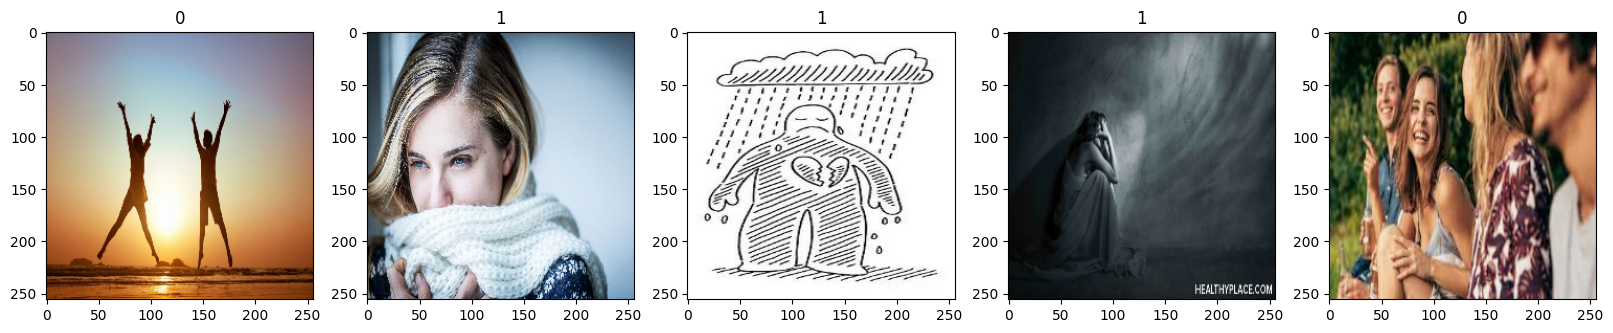

In [15]:
fig, ax = plt.subplots(ncols=5, figsize=(20,20))
for idx, img in enumerate(batch[0][:5]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

In [16]:
data = data.map(lambda x,y: (x/255, y))
#newrel network perform well data into 0 to 1 smaller the data faster the perfomace

In [17]:
data.as_numpy_iterator().next()

(array([[[[0.972549  , 0.972549  , 0.972549  ],
          [0.972549  , 0.972549  , 0.972549  ],
          [0.972549  , 0.972549  , 0.972549  ],
          ...,
          [0.26667732, 0.1686381 , 0.09020673],
          [0.34024623, 0.242207  , 0.16377564],
          [0.33096433, 0.24861139, 0.16625845]],
 
         [[0.972549  , 0.972549  , 0.972549  ],
          [0.972549  , 0.972549  , 0.972549  ],
          [0.972549  , 0.972549  , 0.972549  ],
          ...,
          [0.4149218 , 0.31688255, 0.2384512 ],
          [0.3106899 , 0.21265067, 0.1342193 ],
          [0.32170314, 0.23542863, 0.1530757 ]],
 
         [[0.972549  , 0.972549  , 0.972549  ],
          [0.972549  , 0.972549  , 0.972549  ],
          [0.972549  , 0.972549  , 0.972549  ],
          ...,
          [0.3183146 , 0.2202754 , 0.14184403],
          [0.2903507 , 0.19231148, 0.11388011],
          [0.3132548 , 0.20167392, 0.13001338]],
 
         ...,
 
         [[0.6357727 , 0.62792957, 0.6710668 ],
          [0.64065

In [18]:
train_size = int(len(data)*.7) #70% train
val_size = int(len(data)*.2) #20% validation
test_size = int(len(data)*.1)#10% test

In [19]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

In [20]:
from tensorflow.keras.models import Sequential #singl input and singl output
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

In [21]:
model = Sequential()

In [22]:
model.add(Conv2D(16,(3,3),1,activation='relu',input_shape = (256,256,3)))
model.add(MaxPooling2D())
model.add(Conv2D(32,(3,3),1,activation='relu'))
model.add(MaxPooling2D())
model.add(Conv2D(16,(3,3),1,activation='relu'))
model.add(MaxPooling2D())
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
model.compile('adam',loss=tf.losses.BinaryCrossentropy(),metrics=['accuracy'])

In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,686,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,696,625 (14.10 MB)

 Trainable params: 3,696,625 (14.10 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
logdir = 'logs'

In [26]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [27]:
hist = model.fit(train,epochs=25,validation_data=val,callbacks=tensorboard_callback)

Epoch 1/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 546ms/step - accuracy: 0.5223 - loss: 0.8954 - val_accuracy: 0.5312 - val_loss: 0.6167
Epoch 2/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 811ms/step - accuracy: 0.5714 - loss: 0.6023 - val_accuracy: 0.7188 - val_loss: 0.6106
Epoch 3/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 668ms/step - accuracy: 0.7411 - loss: 0.5411 - val_accuracy: 0.7656 - val_loss: 0.4394
Epoch 4/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 570ms/step - accuracy: 0.7857 - loss: 0.4438 - val_accuracy: 0.9062 - val_loss: 0.3291
Epoch 5/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 864ms/step - accuracy: 0.8170 - loss: 0.3580 - val_accuracy: 0.9375 - val_loss: 0.2917
Epoch 6/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 542ms/step - accuracy: 0.8571 - loss: 0.3215 - val_accuracy: 0.8125 - val_loss: 0.3942
Epoch 7/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 654ms/step - accuracy: 0.8750 - loss: 0.3219 - val_accuracy: 0.9375 - val_loss: 0.2135
Epoch 8/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 778ms/step - accuracy: 0.9241 - loss: 0.2358 - val_accuracy: 0.9062 - val_loss

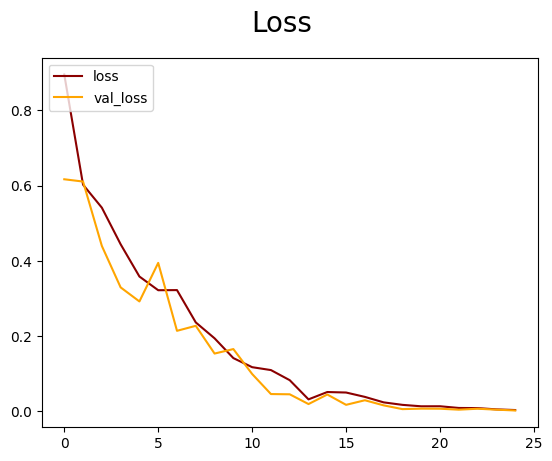

In [29]:
fig = plt.figure()
plt.plot(hist.history['loss'], color='darkred', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

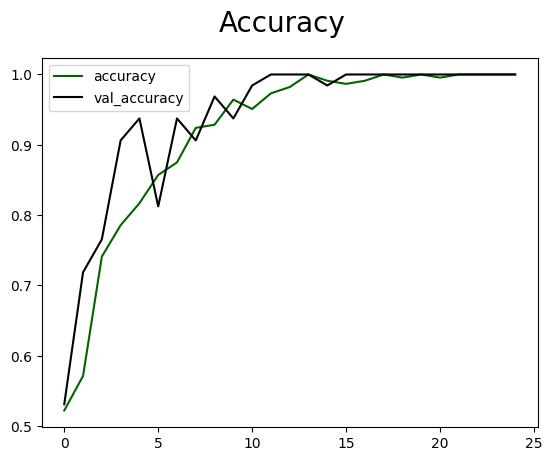

In [30]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color='darkgreen', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='k', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

In [31]:
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy

In [32]:
Pre = Precision()
Re = Recall()
Acc = BinaryAccuracy()

In [33]:
for batch in test.as_numpy_iterator():
    X, y = batch
    yhat = model.predict(X)
    Pre.update_state(y, yhat)
    Re.update_state(y, yhat)
    Acc.update_state(y, yhat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 869ms/step


In [34]:
Pre.result()

<tf.Tensor: shape=(), dtype=float32, numpy=1.0>

In [35]:
print(Re.result())

tf.Tensor(1.0, shape=(), dtype=float32)


In [36]:
print(Acc.result())

tf.Tensor(1.0, shape=(), dtype=float32)


In [37]:
import cv2

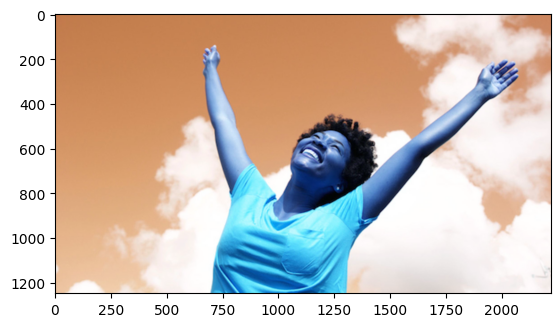

In [38]:
img = cv2.imread('istock-508455188.jpg')
plt.imshow(img)
plt.show()

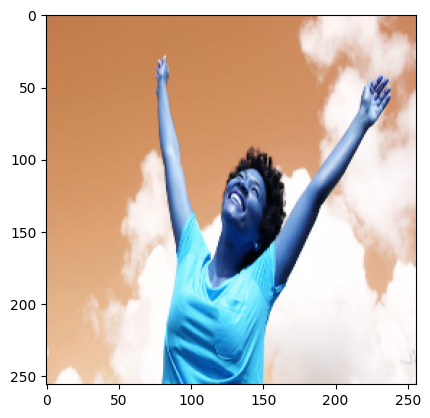

In [39]:
resize = tf.image.resize(img, (256,256))
plt.imshow(resize.numpy().astype(int))
plt.show()

In [40]:
yhat = model.predict(np.expand_dims(resize/255, 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [41]:
yhat

array([[0.00294648]], dtype=float32)

In [42]:
if yhat > 0.5:
    print(f'Predicted class is Sad')
else:
    print(f'Predicted class is Happy')

Predicted class is Happy


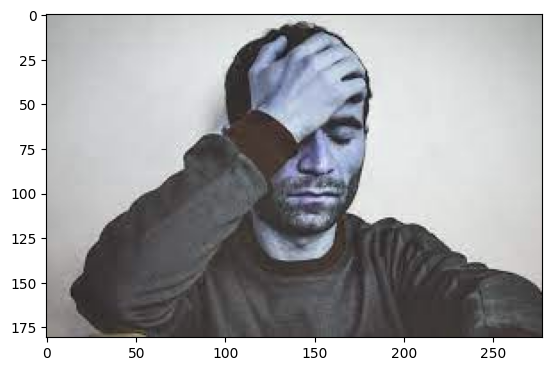

In [49]:
img = cv2.imread('/content/Image_Classification/data/sad/image22.jpeg')
plt.imshow(img)
plt.show()

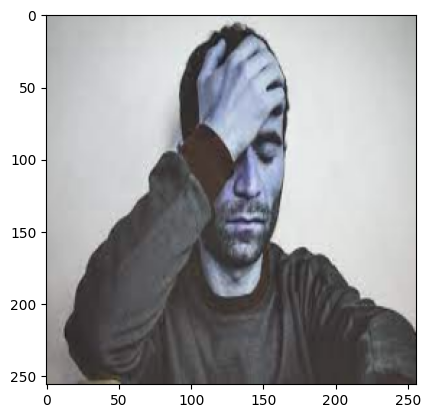

In [50]:
resize = tf.image.resize(img, (256,256))
plt.imshow(resize.numpy().astype(int))
plt.show()

In [51]:
yhat = model.predict(np.expand_dims(resize/255, 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


In [52]:
yhat

array([[0.9924708]], dtype=float32)

In [53]:
if yhat > 0.5:
    print(f'Predicted class is Sad')
else:
    print(f'Predicted class is Happy')

Predicted class is Sad


In [48]:
model.save(os.path.join('models','image_classifier_models.h5'))